In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Abhinav Pullela\OneDrive\Desktop\Signal_Forge


In [3]:
from ml.inference.run import run_semantic_clustering

result = run_semantic_clustering()
print(result.keys())

c:\Users\Abhinav Pullela\OneDrive\Desktop\Signal_Forge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SignalForge Semantic Clustering
Loading SentenceTransformer: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2693.15it/s]


Connected to Neon PostgreSQL!
Loaded 20292 posts from PostgreSQL

First post:
{'post_id': 422, 'source_id': 1, 'community_id': 423, 'external_id': 't4f9bf', 'title': '[ Removed by Reddit ]', 'content': '[removed]', 'published_at': datetime.datetime(2022, 3, 1, 18, 53, 35, tzinfo=zoneinfo.ZoneInfo(key='GMT')), 'permalink': 'https://old.reddit.com/r/datasets/comments/t4f9bf/removed_by_reddit/', 'url': None, 'domain': 'pravda.com.ua', 'score': 7}

Embeddings:
  Shape: (20292, 384)
  Dtype: float32

LABELS:
[ -1  -1 847 ... 493 671 961]

Unique labels:
[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int

In [4]:
embeddings = result["embeddings"]
labels = result["labels"]
posts = result["posts"]
metrics = result["metrics"]

print("Embeddings shape:", embeddings.shape)
print("Number of posts:", len(posts))
print("Number of clusters:", metrics["num_clusters"])
print("Number of noise points:", metrics["num_noise_points"])

Embeddings shape: (20292, 384)
Number of posts: 20292
Number of clusters: 1296
Number of noise points: 13777


In [5]:
print("=" * 60)
print("CLUSTERING EVALUATION")
print("=" * 60)

print(f"Number of posts          : {metrics['num_posts']}")
print(f"Number of clusters       : {metrics['num_clusters']}")
print(f"Number of noise points   : {metrics['num_noise_points']}")

print("\n--- Internal Metrics ---")

print(
    f"Silhouette Score         : "
    f"{metrics['silhouette']:.4f}"
    if metrics["silhouette"] is not None
    else "Silhouette Score         : N/A"
)

print(
    f"Davies-Bouldin Index     : "
    f"{metrics['davies_bouldin']:.4f}"
    if metrics["davies_bouldin"] is not None
    else "Davies-Bouldin Index     : N/A"
)

print(
    f"Calinski-Harabasz Score  : "
    f"{metrics['calinski_harabasz']:.4f}"
    if metrics["calinski_harabasz"] is not None
    else "Calinski-Harabasz Score  : N/A"
)

print("\n--- Ground Truth Metrics ---")

# print(f"Adjusted Rand Index      : {metrics['ari']:.4f}")
# print(f"Normalized Mutual Info   : {metrics['nmi']:.4f}")

CLUSTERING EVALUATION
Number of posts          : 20292
Number of clusters       : 1296
Number of noise points   : 13777

--- Internal Metrics ---
Silhouette Score         : 0.1717
Davies-Bouldin Index     : 1.4983
Calinski-Harabasz Score  : 9.1700

--- Ground Truth Metrics ---


In [6]:
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.04575721 0.0358061 ]
Total explained variance: 0.08156331


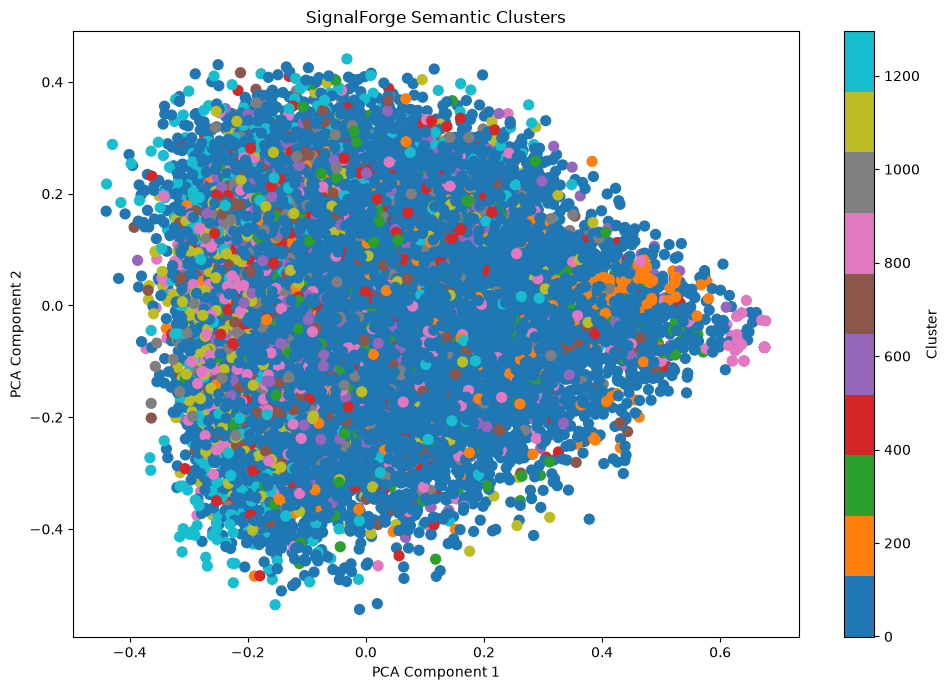

In [7]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SignalForge Semantic Clusters")

plt.colorbar(
    scatter,
    label="Cluster",
)

plt.tight_layout()

plt.show()

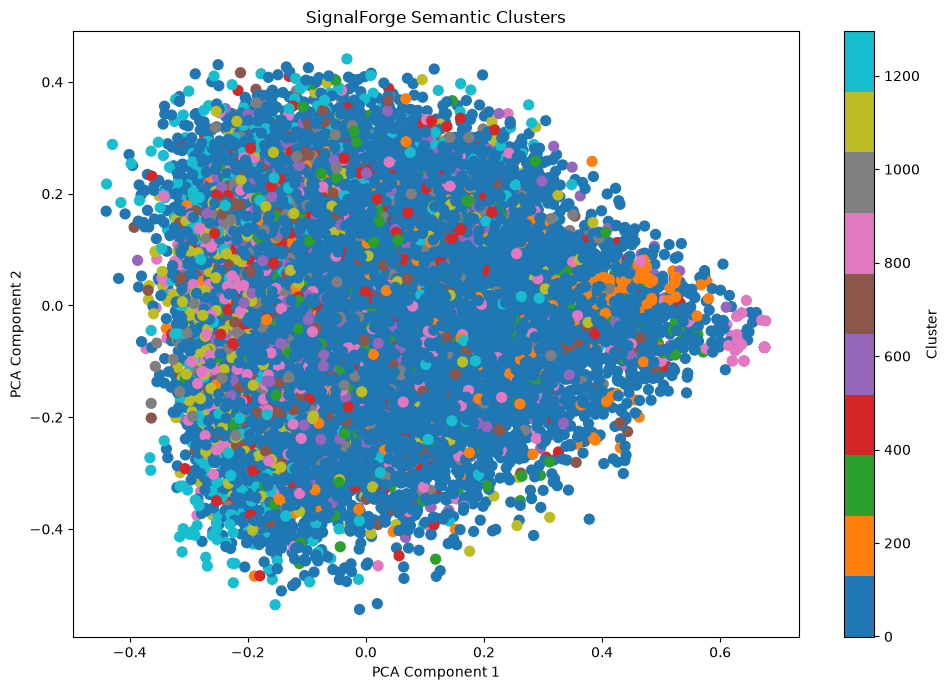

Saved to: c:\Users\Abhinav Pullela\OneDrive\Desktop\Signal_Forge\outputs\semantic_clusters.png


In [8]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_path = OUTPUT_DIR / "semantic_clusters.png"

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SignalForge Semantic Clusters")

plt.colorbar(
    scatter,
    label="Cluster",
)

plt.tight_layout()

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [9]:
for key, value in result.items():
    print(key, type(value))

posts <class 'list'>
embeddings <class 'numpy.ndarray'>
labels <class 'numpy.ndarray'>
metrics <class 'dict'>


In [10]:
posts = result["posts"]
labels = result["labels"]

print("Number of posts:", len(posts))
print("Number of labels:", len(labels))

print("\nFirst post:")
print(posts[0])

print("\nAvailable fields:")
print(posts[0].keys())

Number of posts: 20292
Number of labels: 20292

First post:
{'post_id': 422, 'source_id': 1, 'community_id': 423, 'external_id': 't4f9bf', 'title': '[ Removed by Reddit ]', 'content': '[removed]', 'published_at': datetime.datetime(2022, 3, 1, 18, 53, 35, tzinfo=zoneinfo.ZoneInfo(key='GMT')), 'permalink': 'https://old.reddit.com/r/datasets/comments/t4f9bf/removed_by_reddit/', 'url': None, 'domain': 'pravda.com.ua', 'score': 7}

Available fields:
dict_keys(['post_id', 'source_id', 'community_id', 'external_id', 'title', 'content', 'published_at', 'permalink', 'url', 'domain', 'score'])


In [23]:
import pandas as pd

posts = result["posts"]
labels = result["labels"]

temporal_df = pd.DataFrame({
    "post_id": [post["post_id"] for post in posts],
    "published_at": [post["published_at"] for post in posts],
    "cluster_id": labels
})

print(temporal_df.head())
print("\nShape:", temporal_df.shape)


   post_id              published_at  cluster_id
0      422 2022-03-01 18:53:35+00:00          -1
1      423 2022-03-01 18:36:33+00:00          -1
2      424 2022-03-01 18:00:50+00:00         847
3      425 2022-03-01 14:42:33+00:00         492
4      426 2022-03-01 13:27:55+00:00          -1

Shape: (20292, 3)


In [24]:
print("Timestamp type:")
print(type(temporal_df["published_at"].iloc[0]))

print("\nEarliest post:")
print(temporal_df["published_at"].min())

print("\nLatest post:")
print(temporal_df["published_at"].max())

Timestamp type:
<class 'pandas.Timestamp'>

Earliest post:
2010-04-05 05:53:35+00:00

Latest post:
2022-03-01 18:53:35+00:00


In [25]:
daily_volume = (
    temporal_df
    .set_index("published_at")
    .resample("D")
    .size()
)

print(daily_volume.head(10))
print("\nNumber of days:", len(daily_volume))

print("\nPosts per day:")
print(daily_volume.describe())

published_at
2010-04-05 00:00:00+00:00    46
2010-04-06 00:00:00+00:00    11
2010-04-07 00:00:00+00:00     3
2010-04-08 00:00:00+00:00     1
2010-04-09 00:00:00+00:00     2
2010-04-10 00:00:00+00:00     0
2010-04-11 00:00:00+00:00     0
2010-04-12 00:00:00+00:00     0
2010-04-13 00:00:00+00:00     0
2010-04-14 00:00:00+00:00     0
Freq: D, dtype: int64

Number of days: 4349

Posts per day:
count    4349.000000
mean        4.665900
std         4.577593
min         0.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        46.000000
dtype: float64


In [26]:
# Create a copy for temporal analysis
temporal_df = temporal_df.copy()

# Convert timestamp to daily bucket
temporal_df["date"] = temporal_df["published_at"].dt.floor("D")

# Ignore HDBSCAN noise (-1)
clustered_df = temporal_df[
    temporal_df["cluster_id"] != -1
].copy()

# Count posts per cluster per day
daily_cluster_volume = (
    clustered_df
    .groupby(["date", "cluster_id"])
    .size()
    .reset_index(name="volume")
)

print(daily_cluster_volume.head(20))
print("\nShape:", daily_cluster_volume.shape)

                        date  cluster_id  volume
0  2010-04-05 00:00:00+00:00          86       1
1  2010-04-05 00:00:00+00:00          89       2
2  2010-04-05 00:00:00+00:00          91       1
3  2010-04-05 00:00:00+00:00         298       1
4  2010-04-05 00:00:00+00:00         308       1
5  2010-04-05 00:00:00+00:00         360       1
6  2010-04-05 00:00:00+00:00         493       1
7  2010-04-05 00:00:00+00:00         513       1
8  2010-04-05 00:00:00+00:00         523       1
9  2010-04-05 00:00:00+00:00         588       2
10 2010-04-05 00:00:00+00:00         671       1
11 2010-04-05 00:00:00+00:00         683       1
12 2010-04-05 00:00:00+00:00         732       1
13 2010-04-05 00:00:00+00:00         753       1
14 2010-04-05 00:00:00+00:00         770       1
15 2010-04-05 00:00:00+00:00         961       1
16 2010-04-05 00:00:00+00:00         962       1
17 2010-04-05 00:00:00+00:00        1244       1
18 2010-04-05 00:00:00+00:00        1250       1
19 2010-04-06 00:00:

In [27]:
cluster_id = daily_cluster_volume["cluster_id"].iloc[0]

cluster_history = daily_cluster_volume[
    daily_cluster_volume["cluster_id"] == cluster_id
].sort_values("date")

print("Cluster:", cluster_id)
print(cluster_history.head(20))

Cluster: 86
                          date  cluster_id  volume
0    2010-04-05 00:00:00+00:00          86       1
3443 2019-11-28 00:00:00+00:00          86       1
3451 2019-12-01 00:00:00+00:00          86       1


In [33]:
clustered_df = temporal_df[
    temporal_df["cluster_id"] != -1
].copy()
# Remove HDBSCAN noise for cluster-level analysis

In [ ]:
daily_cluster_volume = (
    clustered_df
    .groupby(["date", "cluster_id"])
    .size()
    .reset_index(name="volume")
)
# Count posts per cluster per day

In [ ]:
start_date = temporal_df["date"].min()
end_date = temporal_df["date"].max()

print("Start:", start_date)
print("End:", end_date)

all_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

print("Number of dates:", len(all_dates))

cluster_ids = sorted(
    clustered_df["cluster_id"].unique()
)

print("Number of clusters:", len(cluster_ids))

Start: 2010-04-05 00:00:00+00:00
End: 2022-03-01 00:00:00+00:00


In [ ]:
all_dates = pd.date_range(
    start=temporal_df["date"].min(),
    end=temporal_df["date"].max(),
    freq="D"
) # Create complete data range

# Semantic Clusters data
cluster_ids = sorted(
    clustered_df["cluster_id"].unique()
)

# Create every date × cluster combination
full_index = pd.MultiIndex.from_product(
    [all_dates, cluster_ids],
    names=["date", "cluster_id"]
)



full_index = pd.MultiIndex.from_product(
    [all_dates, cluster_ids],
    names=["date", "cluster_id"]
)

daily_cluster_volume = (
    daily_cluster_volume
    .set_index(["date", "cluster_id"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(daily_cluster_volume.head(20))

                        date  cluster_id  volume
0  2010-04-05 00:00:00+00:00           0       0
1  2010-04-05 00:00:00+00:00           1       0
2  2010-04-05 00:00:00+00:00           2       0
3  2010-04-05 00:00:00+00:00           3       0
4  2010-04-05 00:00:00+00:00           4       0
5  2010-04-05 00:00:00+00:00           5       0
6  2010-04-05 00:00:00+00:00           6       0
7  2010-04-05 00:00:00+00:00           7       0
8  2010-04-05 00:00:00+00:00           8       0
9  2010-04-05 00:00:00+00:00           9       0
10 2010-04-05 00:00:00+00:00          10       0
11 2010-04-05 00:00:00+00:00          11       0
12 2010-04-05 00:00:00+00:00          12       0
13 2010-04-05 00:00:00+00:00          13       0
14 2010-04-05 00:00:00+00:00          14       0
15 2010-04-05 00:00:00+00:00          15       0
16 2010-04-05 00:00:00+00:00          16       0
17 2010-04-05 00:00:00+00:00          17       0
18 2010-04-05 00:00:00+00:00          18       0
19 2010-04-05 00:00:

In [34]:
print("Daily cluster volume:")
print(daily_cluster_volume.head(20))

print("\nShape:", daily_cluster_volume.shape)

print("\nNumber of dates:", len(all_dates))
print("Number of clusters:", len(cluster_ids))

Daily cluster volume:
                        date  cluster_id  volume
0  2010-04-05 00:00:00+00:00           0       0
1  2010-04-05 00:00:00+00:00           1       0
2  2010-04-05 00:00:00+00:00           2       0
3  2010-04-05 00:00:00+00:00           3       0
4  2010-04-05 00:00:00+00:00           4       0
5  2010-04-05 00:00:00+00:00           5       0
6  2010-04-05 00:00:00+00:00           6       0
7  2010-04-05 00:00:00+00:00           7       0
8  2010-04-05 00:00:00+00:00           8       0
9  2010-04-05 00:00:00+00:00           9       0
10 2010-04-05 00:00:00+00:00          10       0
11 2010-04-05 00:00:00+00:00          11       0
12 2010-04-05 00:00:00+00:00          12       0
13 2010-04-05 00:00:00+00:00          13       0
14 2010-04-05 00:00:00+00:00          14       0
15 2010-04-05 00:00:00+00:00          15       0
16 2010-04-05 00:00:00+00:00          16       0
17 2010-04-05 00:00:00+00:00          17       0
18 2010-04-05 00:00:00+00:00          18       

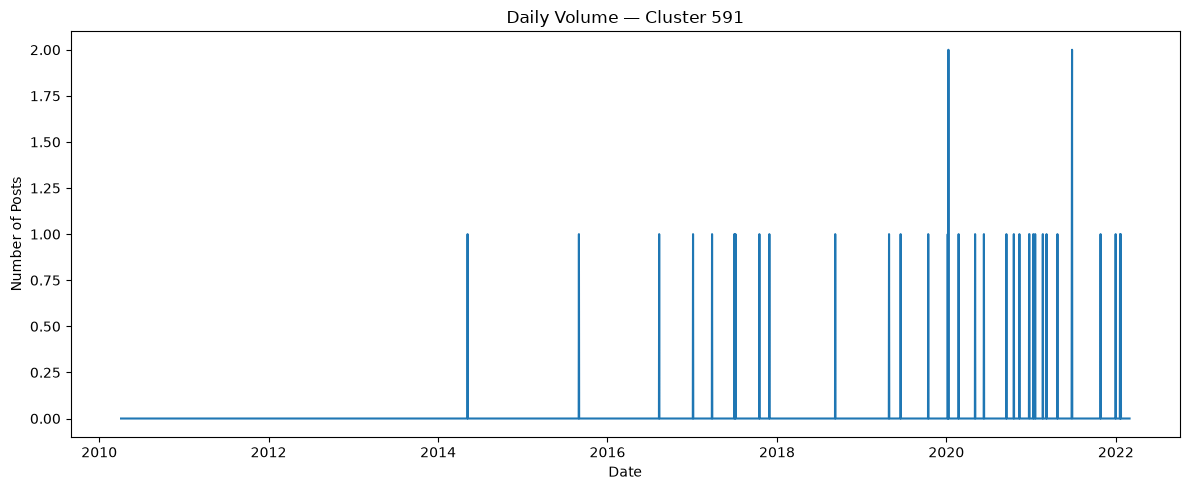

In [35]:
import matplotlib.pyplot as plt

# Pick a cluster with relatively high activity
cluster_totals = (
    daily_cluster_volume
    .groupby("cluster_id")["volume"]
    .sum()
    .sort_values(ascending=False)
)

top_cluster = cluster_totals.index[0]

cluster_history = daily_cluster_volume[
    daily_cluster_volume["cluster_id"] == top_cluster
]

plt.figure(figsize=(12, 5))

plt.plot(
    cluster_history["date"],
    cluster_history["volume"]
)

plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title(f"Daily Volume — Cluster {top_cluster}")

plt.tight_layout()
plt.show()

In [ ]:
# Number of posts that belong to actual clusters
clustered_post_count = len(clustered_df)

# Total posts represented in our daily volume table
volume_total = daily_cluster_volume["volume"].sum()

print("Clustered posts:", clustered_post_count)
print("Total volume:", volume_total)

print("\nMatch:", clustered_post_count == volume_total)

# We need to make sure that our aggregation didn't accidentally lose or duplicate posts.

Clustered posts: 6515
Total volume: 6515

Match: True


In [ ]:
# 
nonzero_volume = daily_cluster_volume[
    daily_cluster_volume["volume"] > 0
]

print("Rows with activity:", len(nonzero_volume))
print("\nFirst active rows:")
print(nonzero_volume.head(20))

Rows with activity: 6218

First active rows:
                          date  cluster_id  volume
86   2010-04-05 00:00:00+00:00          86       1
89   2010-04-05 00:00:00+00:00          89       2
91   2010-04-05 00:00:00+00:00          91       1
298  2010-04-05 00:00:00+00:00         298       1
308  2010-04-05 00:00:00+00:00         308       1
360  2010-04-05 00:00:00+00:00         360       1
493  2010-04-05 00:00:00+00:00         493       1
513  2010-04-05 00:00:00+00:00         513       1
523  2010-04-05 00:00:00+00:00         523       1
588  2010-04-05 00:00:00+00:00         588       2
671  2010-04-05 00:00:00+00:00         671       1
683  2010-04-05 00:00:00+00:00         683       1
732  2010-04-05 00:00:00+00:00         732       1
753  2010-04-05 00:00:00+00:00         753       1
770  2010-04-05 00:00:00+00:00         770       1
961  2010-04-05 00:00:00+00:00         961       1
962  2010-04-05 00:00:00+00:00         962       1
1244 2010-04-05 00:00:00+00:00       

In [ ]:
# Which semantic clusters contain the most posts across the entire dataset?

top_clusters = (
    daily_cluster_volume
    .groupby("cluster_id")["volume"]
    .sum()
    .sort_values(ascending=False)
)

print(top_clusters.head(20))

cluster_id
591     36
729     36
897     33
931     31
1258    30
1056    25
374     25
1276    23
1164    23
1245    22
868     21
1157    21
1144    20
835     20
682     19
510     19
960     18
765     18
1251    18
783     18
Name: volume, dtype: int64


In [ ]:
### GROWTH RATE ###

In [40]:
daily_cluster_volume = daily_cluster_volume.sort_values(
    ["cluster_id", "date"]
).copy()

daily_cluster_volume["volume_change"] = (
    daily_cluster_volume
    .groupby("cluster_id")["volume"]
    .diff()
)

print(daily_cluster_volume.head(20))

                           date  cluster_id  volume  volume_change
0     2010-04-05 00:00:00+00:00           0       0            NaN
1296  2010-04-06 00:00:00+00:00           0       0            0.0
2592  2010-04-07 00:00:00+00:00           0       0            0.0
3888  2010-04-08 00:00:00+00:00           0       0            0.0
5184  2010-04-09 00:00:00+00:00           0       0            0.0
6480  2010-04-10 00:00:00+00:00           0       0            0.0
7776  2010-04-11 00:00:00+00:00           0       0            0.0
9072  2010-04-12 00:00:00+00:00           0       0            0.0
10368 2010-04-13 00:00:00+00:00           0       0            0.0
11664 2010-04-14 00:00:00+00:00           0       0            0.0
12960 2010-04-15 00:00:00+00:00           0       0            0.0
14256 2010-04-16 00:00:00+00:00           0       0            0.0
15552 2010-04-17 00:00:00+00:00           0       0            0.0
16848 2010-04-18 00:00:00+00:00           0       0           

In [41]:
# Find the most active cluster IDs
top_cluster_ids = (
    daily_cluster_volume
    .groupby("cluster_id")["volume"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

for cluster_id in top_cluster_ids:
    print(f"\n===== Cluster {cluster_id} =====")

    cluster_data = daily_cluster_volume[
        daily_cluster_volume["cluster_id"] == cluster_id
    ]

    # Only show days where this cluster had posts
    active_days = cluster_data[cluster_data["volume"] > 0]

    print(
        active_days[
            ["date", "volume", "volume_change"]
        ].head(20)
    )


===== Cluster 591 =====
                             date  volume  volume_change
1936815 2014-05-08 00:00:00+00:00       1            1.0
2558895 2015-08-31 00:00:00+00:00       1            1.0
3007311 2016-08-11 00:00:00+00:00       1            1.0
3196527 2017-01-04 00:00:00+00:00       1            1.0
3302799 2017-03-27 00:00:00+00:00       1            1.0
3427215 2017-07-01 00:00:00+00:00       1            1.0
3433695 2017-07-06 00:00:00+00:00       1            1.0
3567183 2017-10-17 00:00:00+00:00       1            1.0
3622911 2017-11-29 00:00:00+00:00       1            1.0
3990975 2018-09-09 00:00:00+00:00       1            1.0
4291647 2019-04-29 00:00:00+00:00       1            1.0
4356447 2019-06-18 00:00:00+00:00       1            1.0
4510671 2019-10-15 00:00:00+00:00       1            1.0
4619535 2020-01-07 00:00:00+00:00       1            1.0
4623423 2020-01-10 00:00:00+00:00       2            2.0
4680447 2020-02-23 00:00:00+00:00       1            1.0
477246

In [43]:
# How much activity did this cluster have over the recent 7 days?
daily_cluster_volume = daily_cluster_volume.sort_values(
    ["cluster_id", "date"]
).copy()

daily_cluster_volume["rolling_7d_volume"] = (
    daily_cluster_volume
    .groupby("cluster_id")["volume"]
    .transform(
        lambda x: x.rolling(window=7, min_periods=1).sum()
    )
)

print(
    daily_cluster_volume[
        ["date", "cluster_id", "volume", "rolling_7d_volume"]
    ]
)

                             date  cluster_id  volume  rolling_7d_volume
0       2010-04-05 00:00:00+00:00           0       0                0.0
1296    2010-04-06 00:00:00+00:00           0       0                0.0
2592    2010-04-07 00:00:00+00:00           0       0                0.0
3888    2010-04-08 00:00:00+00:00           0       0                0.0
5184    2010-04-09 00:00:00+00:00           0       0                0.0
...                           ...         ...     ...                ...
5631119 2022-02-25 00:00:00+00:00        1295       0                0.0
5632415 2022-02-26 00:00:00+00:00        1295       0                0.0
5633711 2022-02-27 00:00:00+00:00        1295       0                0.0
5635007 2022-02-28 00:00:00+00:00        1295       0                0.0
5636303 2022-03-01 00:00:00+00:00        1295       0                0.0

[5636304 rows x 4 columns]


In [44]:
top_recent = (
    daily_cluster_volume
    .sort_values("rolling_7d_volume", ascending=False)
)

print(
    top_recent[
        ["date", "cluster_id", "volume", "rolling_7d_volume"]
    ].head(30)
)

                             date  cluster_id  volume  rolling_7d_volume
2504090 2015-07-20 00:00:00+00:00         218       0               13.0
2505386 2015-07-21 00:00:00+00:00         218       0               13.0
2501498 2015-07-18 00:00:00+00:00         218       0               13.0
2500202 2015-07-17 00:00:00+00:00         218       7               13.0
2502794 2015-07-19 00:00:00+00:00         218       0               13.0
2496323 2015-07-14 00:00:00+00:00         227       0                8.0
2495027 2015-07-13 00:00:00+00:00         227       8                8.0
4703586 2020-03-12 00:00:00+00:00         402       8                8.0
2497619 2015-07-15 00:00:00+00:00         227       0                8.0
2498915 2015-07-16 00:00:00+00:00         227       0                8.0
2500211 2015-07-17 00:00:00+00:00         227       0                8.0
2501507 2015-07-18 00:00:00+00:00         227       0                8.0
2502803 2015-07-19 00:00:00+00:00         227      